In [10]:
from datasets import load_dataset

train_dataset = load_dataset("google-research-datasets/go_emotions", split="train")
valid_dataset = load_dataset("google-research-datasets/go_emotions", split="validation")


In [11]:
import pandas as pd

test_dataset = pd.read_csv('transcript_spell_checked.csv')
test = test_dataset.rename(columns={"Translation": "text"})
test.head()

,Start Time,End Time,Sentence,text,Emotion_fine,Emotion_core,Intensity,sentence_length,emotion_coverage,predicted_emotion,emotion_final,Sentence_corrected
0,00:00:00,00:00:07,Program zawiera treści nieodpowiednie dla widz...,The program contains content inappropriate for...,warning,fear,mild,14,1,disgust,disgust,Program zawiera treści nieodpowiednie dla widz...
1,00:00:07,00:00:09,Oglądasz na własną odpowiedzialność.,You watch at your own risk.,caution,fear,mild,4,1,fear,fear,Oglądasz na własną odpowiedzialność.
2,00:00:10,00:00:13,Jedziemy do Piękowa!,We're going to Pięków!,excitement,happiness,moderate,3,1,happiness,happiness,Jedziemy do Piękowa!
3,00:00:14,00:00:17,"Krakowiacek jeden, a okoliców siedem.","One Krakowiacek, and seven surroundings.",pride,happiness,mild,5,1,neutral,happiness,"Krakowiacek jeden, a okoliców siedem."
4,00:00:19,00:00:22,"Tak go dźgnąłem w tą tarczę i widziałem, że si...",So I stabbed him in that shield and I saw that...,irritation,anger,moderate,11,1,anger,anger,"Tak go dźgnąłem w tą tarczę i widziałem, że si..."


In [12]:
train = pd.DataFrame(data=train_dataset)
valid = pd.DataFrame(data=valid_dataset)
display(train.head())
display(valid.head())

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


,text,labels,id
0,Is this in New Orleans?? I really feel like th...,[27],edgurhb
1,"You know the answer man, you are programmed to...","[4, 27]",ee84bjg
2,I've never been this sad in my life!,[25],edcu99z
3,The economy is heavily controlled and subsidiz...,"[4, 27]",edc32e2
4,He could have easily taken a real camera from ...,[20],eepig6r


In [47]:
display(train.shape, test.shape, valid.shape)

(43410, 9)

(469, 16)

(5426, 7)

In [13]:
emotions = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness",
    "optimism", "pride", "realization", "relief", "remorse",
    "sadness", "surprise", "neutral"
]
train["emotion_text"] = train["labels"].apply(lambda x: [emotions[i] for i in x])
train.head()

,text,labels,id,emotion_text
0,My favourite food is anything I didn't have to...,[27],eebbqej,[neutral]
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i,[neutral]
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj,[anger]
3,To make her feel threatened,[14],ed7ypvh,[fear]
4,Dirty Southern Wankers,[3],ed0bdzj,[annoyance]


In [14]:
emotion_ekman_mapping = {
"anger": ["anger", "annoyance", "disapproval"],
"disgust": ["disgust"],
"fear": ["fear", "nervousness"],
"happiness": ["joy", "amusement", "approval", "excitement", "gratitude",
              "love", "optimism", "relief", "pride", "admiration",
              "desire", "caring"],
"sadness": ["sadness", "disappointment", "embarrassment", "grief",  "remorse"],
"surprise": ["surprise", "realization", "confusion", "curiosity"],
"neutral": ["neutral"]
}

train["Emotion_core"] = train["emotion_text"].apply(
    lambda x: next((k for k, v in emotion_ekman_mapping.items() if any(i in v for i in x)), None)
)
train.head()

,text,labels,id,emotion_text,Emotion_core
0,My favourite food is anything I didn't have to...,[27],eebbqej,[neutral],neutral
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i,[neutral],neutral
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj,[anger],anger
3,To make her feel threatened,[14],ed7ypvh,[fear],fear
4,Dirty Southern Wankers,[3],ed0bdzj,[annoyance],anger


In [15]:
import spacy

# !python -m spacy download en_core_web_lg

nlp = spacy.load("en_core_web_lg")

train_texts = train["text"].tolist()
test_texts = test["text"].tolist()
valid_texts = valid["text"].tolist()

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Helper functions

def lemmas_creator(texts):
    documents_lem = []
    for text in texts:
        documents_lem.append(nlp(text.lower()))
    lemmas = [[token.lemma_ for token in doc if not token.is_punct]
    for doc in documents_lem]
    return lemmas

def to_string_list(column):
    return column.apply(lambda x: " ".join(x) if isinstance(x, list) else "")

# def vectorizer_creator(column):
#     vectorizer = TfidfVectorizer()
#     X = vectorizer.fit_transform(column)
#     tfidf_vectors = X.toarray().tolist()
#     return tfidf_vectors

In [17]:
# lemmas creation
train['lemmas'] = lemmas_creator(train_texts)
test['lemmas'] = lemmas_creator(test_texts)
valid['lemmas'] = lemmas_creator(valid_texts)

# convert list of lemmas to space-separated string
train["lemmas_text"] = to_string_list(train["lemmas"])
test["lemmas_text"] = to_string_list(test["lemmas"])
valid["lemmas_text"] = to_string_list(valid["lemmas"])

In [18]:
train.head()

,text,labels,id,emotion_text,Emotion_core,lemmas,lemmas_text
0,My favourite food is anything I didn't have to...,[27],eebbqej,[neutral],neutral,"[my, favourite, food, be, anything, I, do, not...",my favourite food be anything I do not have to...
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i,[neutral],neutral,"[now, if, he, do, off, himself, everyone, will...",now if he do off himself everyone will think h...
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj,[anger],anger,"[why, the, fuck, be, bayless, isoe]",why the fuck be bayless isoe
3,To make her feel threatened,[14],ed7ypvh,[fear],fear,"[to, make, she, feel, threaten]",to make she feel threaten
4,Dirty Southern Wankers,[3],ed0bdzj,[annoyance],anger,"[dirty, southern, wanker]",dirty southern wanker


In [19]:
test.head()

,Start Time,End Time,Sentence,text,Emotion_fine,Emotion_core,Intensity,sentence_length,emotion_coverage,predicted_emotion,emotion_final,Sentence_corrected,lemmas,lemmas_text
0,00:00:00,00:00:07,Program zawiera treści nieodpowiednie dla widz...,The program contains content inappropriate for...,warning,fear,mild,14,1,disgust,disgust,Program zawiera treści nieodpowiednie dla widz...,"[the, program, contain, content, inappropriate...",the program contain content inappropriate for ...
1,00:00:07,00:00:09,Oglądasz na własną odpowiedzialność.,You watch at your own risk.,caution,fear,mild,4,1,fear,fear,Oglądasz na własną odpowiedzialność.,"[you, watch, at, your, own, risk]",you watch at your own risk
2,00:00:10,00:00:13,Jedziemy do Piękowa!,We're going to Pięków!,excitement,happiness,moderate,3,1,happiness,happiness,Jedziemy do Piękowa!,"[we, be, go, to, pięków]",we be go to pięków
3,00:00:14,00:00:17,"Krakowiacek jeden, a okoliców siedem.","One Krakowiacek, and seven surroundings.",pride,happiness,mild,5,1,neutral,happiness,"Krakowiacek jeden, a okoliców siedem.","[one, krakowiacek, and, seven, surrounding]",one krakowiacek and seven surrounding
4,00:00:19,00:00:22,"Tak go dźgnąłem w tą tarczę i widziałem, że si...",So I stabbed him in that shield and I saw that...,irritation,anger,moderate,11,1,anger,anger,"Tak go dźgnąłem w tą tarczę i widziałem, że si...","[so, I, stab, he, in, that, shield, and, I, se...",so I stab he in that shield and I see that he ...


## Baseline

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline

encoder = LabelEncoder()
y_train = encoder.fit_transform(train['Emotion_core'])
y_test = encoder.transform(test['emotion_final'])

X_train = train["lemmas_text"]
X_test = test["lemmas_text"]

# log_reg = LogisticRegression(max_iter=2000)

log_reg = Pipeline([
    ("lemmas", TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=2)),
    ("lr", LogisticRegression(max_iter=2000))  # n_jobs only if using saga/liblinear accordingly
])

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred, target_names=encoder.classes_, digits=3))

              precision    recall  f1-score   support

       anger      0.522     0.449     0.483        78
     disgust      0.000     0.000     0.000        24
        fear      1.000     0.133     0.235        30
   happiness      0.653     0.492     0.561       126
     neutral      0.372     0.856     0.518       125
     sadness      1.000     0.051     0.098        39
    surprise      0.583     0.149     0.237        47

    accuracy                          0.463       469
   macro avg      0.590     0.304     0.305       469
weighted avg      0.567     0.463     0.416       469



## First Iteration 

In [21]:
def pos_creator(texts, nlp, batch_size=512, n_process=1, join=False):
    """
    texts: iterable of strings
    nlp: a loaded spaCy model
    join: if True, return space-joined POS strings (good for vectorizers)
    """
    # Ensure strings, replace NaNs/None
    texts = [(t if isinstance(t, str) else "") for t in texts]

    pos_per_doc = []
    # Disable components you don't need for POS to speed things up
    with nlp.select_pipes(disable=["ner", "parser"]):
        for doc in nlp.pipe(texts, batch_size=batch_size, n_process=n_process):
            tags = [tok.pos_ for tok in doc]
            pos_per_doc.append(" ".join(tags) if join else tags)
    return pos_per_doc


In [22]:
train['pos_tags'] = pos_creator(train_texts, nlp)
test['pos_tags'] = pos_creator(test_texts, nlp)
valid['pos_tags'] = pos_creator(valid_texts, nlp)

train["pos_str"] = to_string_list(train["pos_tags"])
test["pos_str"]  = to_string_list(test["pos_tags"])
valid["pos_str"] = to_string_list(valid["pos_tags"])

In [23]:
train.head()

,text,labels,id,emotion_text,Emotion_core,lemmas,lemmas_text,pos_tags,pos_str
0,My favourite food is anything I didn't have to...,[27],eebbqej,[neutral],neutral,"[my, favourite, food, be, anything, I, do, not...",my favourite food be anything I do not have to...,"[PRON, ADJ, NOUN, AUX, PRON, PRON, AUX, PART, ...",PRON ADJ NOUN AUX PRON PRON AUX PART AUX PART ...
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i,[neutral],neutral,"[now, if, he, do, off, himself, everyone, will...",now if he do off himself everyone will think h...,"[INTJ, SCONJ, PRON, AUX, ADP, PRON, PUNCT, PRO...",INTJ SCONJ PRON AUX ADP PRON PUNCT PRON AUX VE...
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj,[anger],anger,"[why, the, fuck, be, bayless, isoe]",why the fuck be bayless isoe,"[SCONJ, DET, NOUN, AUX, PROPN, PROPN]",SCONJ DET NOUN AUX PROPN PROPN
3,To make her feel threatened,[14],ed7ypvh,[fear],fear,"[to, make, she, feel, threaten]",to make she feel threaten,"[PART, VERB, PRON, VERB, VERB]",PART VERB PRON VERB VERB
4,Dirty Southern Wankers,[3],ed0bdzj,[annoyance],anger,"[dirty, southern, wanker]",dirty southern wanker,"[ADJ, ADJ, NOUN]",ADJ ADJ NOUN


In [24]:
from sklearn.compose import ColumnTransformer

X_train = train[["lemmas_text", "pos_str"]]
X_test = test[["lemmas_text", "pos_str"]]

preprocess = ColumnTransformer(
    transformers=[
        ("lemmas", TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=1),
         "lemmas_text"),
        ("pos",    TfidfVectorizer(ngram_range=(1,1), min_df=1, lowercase=False, binary=True),
         "pos_str"),
    ],
    remainder="drop"
)

log_reg = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000))  # n_jobs only if using saga/liblinear accordingly
])

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred, target_names=encoder.classes_, digits=3))

              precision    recall  f1-score   support

       anger      0.500     0.436     0.466        78
     disgust      0.000     0.000     0.000        24
        fear      1.000     0.133     0.235        30
   happiness      0.652     0.460     0.540       126
     neutral      0.363     0.848     0.508       125
     sadness      0.667     0.051     0.095        39
    surprise      0.583     0.149     0.237        47

    accuracy                          0.450       469
   macro avg      0.538     0.297     0.297       469
weighted avg      0.533     0.450     0.405       469



In [25]:
X_train = train[["lemmas_text", "pos_str", "text"]]
X_test = test[["lemmas_text", "pos_str", "text"]]

preprocess = ColumnTransformer(
    transformers=[
        ("lemmas", TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=1),
         "lemmas_text"),
        ("pos",    TfidfVectorizer(ngram_range=(1,1), min_df=1, lowercase=False, binary=True),
         "pos_str"),
        ("text)", TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=1), "text")
    ],
    remainder="drop"
)

log_reg = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000))  # n_jobs only if using saga/liblinear accordingly
])

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred, target_names=encoder.classes_, digits=3))

              precision    recall  f1-score   support

       anger      0.543     0.487     0.514        78
     disgust      0.000     0.000     0.000        24
        fear      1.000     0.167     0.286        30
   happiness      0.630     0.460     0.532       126
     neutral      0.364     0.816     0.504       125
     sadness      0.400     0.051     0.091        39
    surprise      0.438     0.149     0.222        47

    accuracy                          0.452       469
   macro avg      0.482     0.304     0.307       469
weighted avg      0.498     0.452     0.411       469



In [26]:
X_train = train[["pos_str", "text"]]
X_test = test[["pos_str", "text"]]

preprocess = ColumnTransformer(
    transformers=[
        ("pos",    TfidfVectorizer(ngram_range=(1,1), min_df=1, lowercase=False, binary=True),
         "pos_str"),
        ("text)", TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=1), "text")
    ],
    remainder="drop"
)

log_reg = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000))  # n_jobs only if using saga/liblinear accordingly
])

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred, target_names=encoder.classes_, digits=3))

              precision    recall  f1-score   support

       anger      0.531     0.436     0.479        78
     disgust      0.000     0.000     0.000        24
        fear      1.000     0.167     0.286        30
   happiness      0.562     0.397     0.465       126
     neutral      0.337     0.792     0.473       125
     sadness      1.000     0.051     0.098        39
    surprise      0.429     0.128     0.197        47

    accuracy                          0.418       469
   macro avg      0.551     0.281     0.285       469
weighted avg      0.519     0.418     0.377       469



The problem is imbalance of train dataset. Below wy try to take care of it for `LogisticRegression`

Emotion_core
happiness    16920
neutral      12823
anger         5579
surprise      4160
sadness       2599
fear           691
disgust        638
Name: count, dtype: int64

<Axes: xlabel='Emotion_core'>

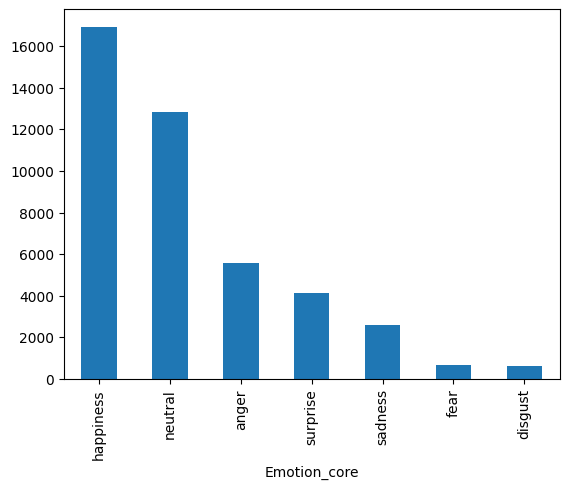

In [27]:
counts_before = train["Emotion_core"].value_counts()

display(counts_before)
display(counts_before.plot(kind='bar'))

## Data augmentation

To increase number of entries with emotions that are underpresented we used `NLTK` [Link](https://github.com/jasonwei20/eda_nlp).

Firstly, we have to download a base for synonyms.

In [ ]:
import nltk
nltk.download("wordnet")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Uni\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [29]:
import pandas as pd

DST_TXT = "train_clean.txt"

# Keep only your columns and drop empties
df = train[["Emotion_core", "text"]].dropna()

emotions_to_keep = ["disgust", "sadness", "fear", "surprise"]
df = df[df["Emotion_core"].isin(emotions_to_keep)]

# Clean text: remove tabs/newlines and trim
def clean_text(s):
    s = str(s)
    s = s.replace("\t", " ").replace("\r", " ").replace("\n", " ").strip()
    return " ".join(s.split())  # collapse multiple spaces

df["text"] = df["text"].map(clean_text)
df["Emotion_core"] = df["Emotion_core"].astype(str).str.strip()

# Drop rows where translation ended up empty after cleaning
df = df[df["text"] != ""]

# Save as TAB-separated, no header/index, UTF-8
df.to_csv(DST_TXT, sep="\t", index=False, header=False, encoding="utf-8")

print(f"✅ Wrote {DST_TXT} with {len(df):,} rows")


✅ Wrote train_clean.txt with 8,088 rows


Command used for EDA (found on repository linked above): `python -X utf8 augment.py --input=train_clean.txt --output=augmented.txt --num_aug=9 --alpha_sr=0.1 --alpha_rd=0.1 --alpha_ri=0.1 --alpha_rs=0.1`

Where:
- `-X utf8` forces python to use utf8 encoding for the file
- `alpha_...` - `sr` for synonyms, `rd` for deletion words from phrases, `rs` for random swap, and `ri` for random insetions. Values are in *% 0.1 = 10%*

### TEST!

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# # 1) Load your original clean file (the one you fed to EDA) and the augmented output
# orig = pd.read_csv("train_clean.txt", sep="\t", header=None, names=["emotion_final", "Translation"], encoding="utf-8")
# aug  = pd.read_csv("augmented.txt",  sep="\t", header=None, names=["emotion_final", "Translation"], encoding="utf-8")

# # 2) Combine (you can also downsample aug if it’s huge)
# df = pd.concat([orig, aug], ignore_index=True)

# # (optional) remove exact duplicates to avoid overfitting on identical lines
# df = df.drop_duplicates(subset=["emotion_final", "Translation"]).reset_index(drop=True)


In [ ]:
# import pandas as pd

# # Convert augmented.txt -> augmented.csv
# df_aug = pd.read_csv("augmented.txt", sep="\t", header=None, names=["Emotion_core", "text"], encoding="utf-8")
# df_aug.to_csv("augmented.csv", index=False, encoding="utf-8")

# print("✅ Saved train_clean.csv and augmented.csv with 2 columns [Emotion_core, text]")

✅ Saved train_clean.csv and augmented.csv with 2 columns [Emotion_core, text]


In [ ]:
# df_combined = pd.concat([train, df_aug], ignore_index=True)

# # Drop duplicates based on the text column only
# df_combined = df_combined.drop_duplicates(subset=["text"]).reset_index(drop=True)

In [ ]:
# counts_after = df_combined["Emotion_core"].value_counts()
# print("After EDA:\n", counts_after)

After EDA:
 Emotion_core
surprise     43070
sadness      26812
happiness    16811
neutral      12789
fear          7047
disgust       6564
anger         5567
Name: count, dtype: int64


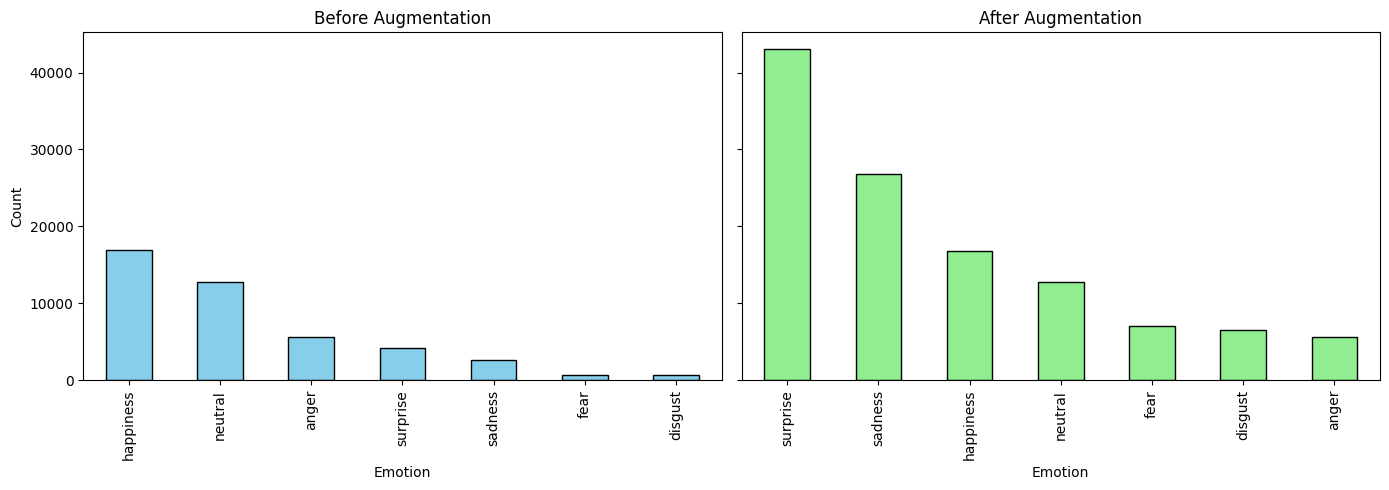

In [ ]:
# import matplotlib.pyplot as plt

# # --- Plot side by side ---
# fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# # left: before
# counts_before.plot(kind="bar", ax=ax[0], color="skyblue", edgecolor="black")
# ax[0].set_title("Before Augmentation")
# ax[0].set_xlabel("Emotion")
# ax[0].set_ylabel("Count")

# # right: after
# counts_after.plot(kind="bar", ax=ax[1], color="lightgreen", edgecolor="black")
# ax[1].set_title("After Augmentation")
# ax[1].set_xlabel("Emotion")

# plt.tight_layout()
# plt.show()

In [ ]:
# train_texts = df_combined["text"].tolist()

# df_combined['lemmas'] = lemmas_creator(train_texts)
# df_combined["lemmas_text"] = to_string_list(df_combined["lemmas"])

# df_combined['pos_tags'] = pos_creator(train_texts, nlp)
# df_combined["pos_str"] = to_string_list(df_combined["pos_tags"])

In [ ]:
# df_combined.head()

,text,labels,id,emotion_text,Emotion_core,lemmas,lemmas_text,pos_tags,pos_str
0,My favourite food is anything I didn't have to...,[27],eebbqej,[neutral],neutral,"[my, favourite, food, be, anything, I, do, not...",my favourite food be anything I do not have to...,"[PRON, ADJ, NOUN, AUX, PRON, PRON, AUX, PART, ...",PRON ADJ NOUN AUX PRON PRON AUX PART AUX PART ...
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i,[neutral],neutral,"[now, if, he, do, off, himself, everyone, will...",now if he do off himself everyone will think h...,"[INTJ, SCONJ, PRON, AUX, ADP, PRON, PUNCT, PRO...",INTJ SCONJ PRON AUX ADP PRON PUNCT PRON AUX VE...
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj,[anger],anger,"[why, the, fuck, be, bayless, isoe]",why the fuck be bayless isoe,"[SCONJ, DET, NOUN, AUX, PROPN, PROPN]",SCONJ DET NOUN AUX PROPN PROPN
3,To make her feel threatened,[14],ed7ypvh,[fear],fear,"[to, make, she, feel, threaten]",to make she feel threaten,"[PART, VERB, PRON, VERB, VERB]",PART VERB PRON VERB VERB
4,Dirty Southern Wankers,[3],ed0bdzj,[annoyance],anger,"[dirty, southern, wanker]",dirty southern wanker,"[ADJ, ADJ, NOUN]",ADJ ADJ NOUN


In [ ]:
# X_train = df_combined["lemmas_text"]
# X_test = test["lemmas_text"]

# y_train = encoder.fit_transform(df_combined['Emotion_core'])
# y_test = encoder.transform(test['emotion_final'])
# # log_reg = LogisticRegression(max_iter=2000)

# log_reg = Pipeline([
#     ("lemmas", TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=2)),
#     ("lr", LogisticRegression(max_iter=2000))  # n_jobs only if using saga/liblinear accordingly
# ])

# log_reg.fit(X_train, y_train)
# y_pred = log_reg.predict(X_test)

# print(classification_report(y_test, y_pred, target_names=encoder.classes_, digits=3))

              precision    recall  f1-score   support

       anger      0.518     0.372     0.433        78
     disgust      0.000     0.000     0.000        24
        fear      0.700     0.233     0.350        30
   happiness      0.803     0.421     0.552       126
     neutral      0.367     0.440     0.400       125
     sadness      0.170     0.205     0.186        39
    surprise      0.129     0.383     0.194        47

    accuracy                          0.362       469
   macro avg      0.384     0.293     0.302       469
weighted avg      0.471     0.362     0.384       469



### Agumentation

After many attempts the most promissing results are after replace words with synonyms.

The process is divided by 3 sections since this approach let us have control over the size of the agumentation

In [38]:
import pandas as pd

DST_TXT1 = "train_clean1.txt"
# Keep only your columns and drop empties
df1 = train[["Emotion_core", "text"]].dropna()

emotions_to_keep_1 = ["disgust", "fear"]
df1 = df1[df1["Emotion_core"].isin(emotions_to_keep_1)]

df1["text"] = df1["text"].map(clean_text)
df1["Emotion_core"] = df1["Emotion_core"].astype(str).str.strip()

# Drop rows where translation ended up empty after cleaning
df1 = df1[df1["text"] != ""]

# Save as TAB-separated, no header/index, UTF-8
df1.to_csv(DST_TXT1, sep="\t", index=False, header=False, encoding="utf-8")

print(f"✅ Wrote {DST_TXT1} with {len(df1):,} rows")


✅ Wrote train_clean1.txt with 1,329 rows


`python -X utf8 augment.py --input=train_clean1.txt --output=augmented1.txt --num_aug=25 --alpha_sr=0.1 --alpha_rd=0.0 --alpha_ri=0.0 --alpha_rs=0.0`

In [39]:
import pandas as pd

DST_TXT2 = "train_clean2.txt"
# Keep only your columns and drop empties
df2 = train[["Emotion_core", "text"]].dropna()

emotions_to_keep_2 = ["surprise", "anger", "sadness"]

df2 = df2[df2["Emotion_core"].isin(emotions_to_keep_2)]

df2["text"] = df2["text"].map(clean_text)
df2["Emotion_core"] = df2["Emotion_core"].astype(str).str.strip()

# Drop rows where translation ended up empty after cleaning
df2 = df2[df2["text"] != ""]

# Save as TAB-separated, no header/index, UTF-8
df2.to_csv(DST_TXT2, sep="\t", index=False, header=False, encoding="utf-8")

print(f"✅ Wrote {DST_TXT2} with {len(df2):,} rows")


✅ Wrote train_clean2.txt with 12,338 rows


`python -X utf8 augment.py --input=train_clean2.txt --output=augmented2.txt --num_aug=3 --alpha_sr=0.1 --alpha_rd=0.0 --alpha_ri=0.0 --alpha_rs=0.0`

In [40]:
import pandas as pd
# from pathlib import Path

# DST_TXT3 = "train_clean3.txt"
# # Keep only your columns and drop empties
# df3 = train[["Emotion_core", "text"]].dropna()

# emotions_to_keep_3 = ["sadness"]
# df3 = df3[df3["Emotion_core"].isin(emotions_to_keep_3)]

# df3["text"] = df3["text"].map(clean_text)
# df3["Emotion_core"] = df3["Emotion_core"].astype(str).str.strip()

# # Drop rows where translation ended up empty after cleaning
# df3 = df3[df3["text"] != ""]

# # Save as TAB-separated, no header/index, UTF-8
# df3.to_csv(DST_TXT3, sep="\t", index=False, header=False, encoding="utf-8")

# print(f"✅ Wrote {DST_TXT3} with {len(df2):,} rows")


Third part was tested for `sadness` class to have possibility to balance better that class. After many tests we did agumentation in part 2 with other classes

`python -X utf8 augment.py --input=train_clean3.txt --output=augmented3.txt --num_aug=12 --alpha_sr=0.1 --alpha_rd=0.0 --alpha_ri=0.0 --alpha_rs=0.0`

In [41]:
import pandas as pd

# Convert augmented.txt -> augmented.csv
df_aug1 = pd.read_csv("augmented1.txt", sep="\t", header=None, names=["Emotion_core", "text"], encoding="utf-8")
df_aug1.to_csv("augmented1.csv", index=False, encoding="utf-8")

df_aug2 = pd.read_csv("augmented2.txt", sep="\t", header=None, names=["Emotion_core", "text"], encoding="utf-8")
df_aug2.to_csv("augmented2.csv", index=False, encoding="utf-8")

df_aug3 = pd.read_csv("augmented3.txt", sep="\t", header=None, names=["Emotion_core", "text"], encoding="utf-8")
df_aug3.to_csv("augmented3.csv", index=False, encoding="utf-8")

print("✅ Saved train_clean.csv and augmented.csv with 2 columns [Emotion_core, text]")

✅ Saved train_clean.csv and augmented.csv with 2 columns [Emotion_core, text]


In [42]:
df_combined_2 = pd.concat([train, df_aug1, df_aug2], ignore_index=True)

# Drop duplicates based on the text column only
df_combined_2 = df_combined_2.drop_duplicates(subset=["text"]).reset_index(drop=True)

In [43]:
counts_after_2 = df_combined_2["Emotion_core"].value_counts()
counts_after_2

Emotion_core
happiness    16811
anger        16613
neutral      12789
surprise     12399
sadness       7733
fear          5661
disgust       5278
Name: count, dtype: int64

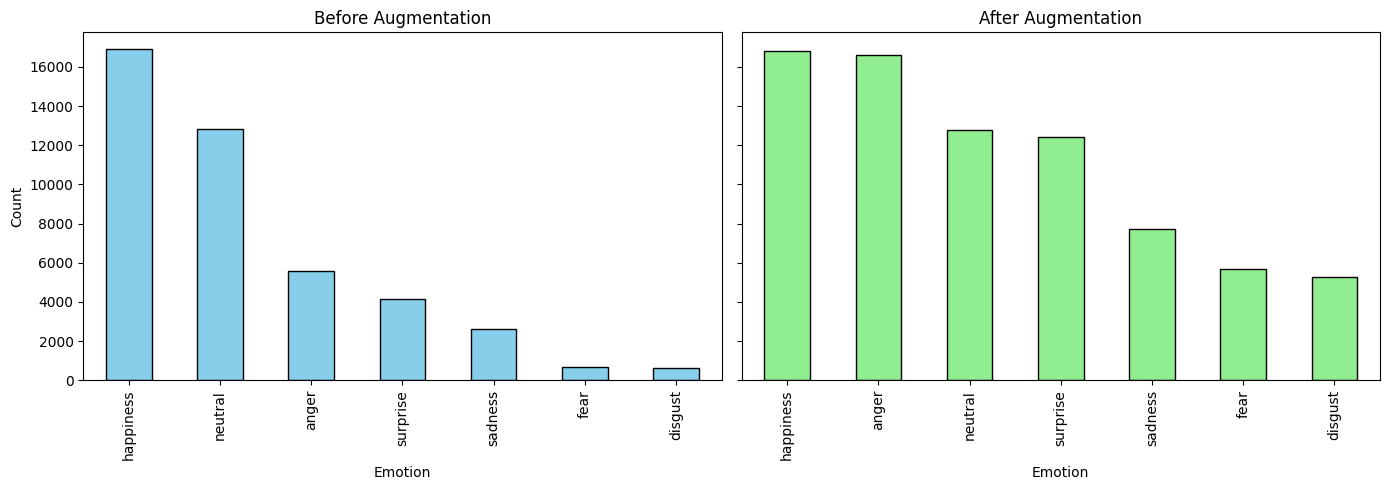

In [44]:
import matplotlib.pyplot as plt

# --- Plot side by side ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# left: before
counts_before.plot(kind="bar", ax=ax[0], color="skyblue", edgecolor="black")
ax[0].set_title("Before Augmentation")
ax[0].set_xlabel("Emotion")
ax[0].set_ylabel("Count")

# right: after
counts_after_2.plot(kind="bar", ax=ax[1], color="lightgreen", edgecolor="black")
ax[1].set_title("After Augmentation")
ax[1].set_xlabel("Emotion")

plt.tight_layout()
plt.show()

The dataset is more balanced than before. However, there is still insufficient data for the `fear` and `disgust` classes to achieve full balance. Excessive augmentation for these categories risks altering the original sentence meaning, which could lead to incorrect class labels.

In [45]:
train_texts = df_combined_2["text"].tolist()

df_combined_2['lemmas'] = lemmas_creator(train_texts)
df_combined_2["lemmas_text"] = to_string_list(df_combined_2["lemmas"])

df_combined_2['pos_tags'] = pos_creator(train_texts, nlp)
df_combined_2["pos_str"] = to_string_list(df_combined_2["pos_tags"])

In [46]:
X_train = df_combined_2["lemmas_text"]
X_test = test["lemmas_text"]

y_train = encoder.fit_transform(df_combined_2['Emotion_core'])
y_test = encoder.transform(test['emotion_final'])
# log_reg = LogisticRegression(max_iter=2000)

log_reg = Pipeline([
    ("lemmas", TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=2)),
    ("lr", LogisticRegression(max_iter=2000))  # n_jobs only if using saga/liblinear accordingly
])

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred, target_names=encoder.classes_, digits=3))

              precision    recall  f1-score   support

       anger      0.402     0.577     0.474        78
     disgust      0.000     0.000     0.000        24
        fear      0.778     0.233     0.359        30
   happiness      0.756     0.468     0.578       126
     neutral      0.394     0.672     0.497       125
     sadness      0.400     0.154     0.222        39
    surprise      0.220     0.191     0.205        47

    accuracy                          0.448       469
   macro avg      0.421     0.328     0.334       469
weighted avg      0.480     0.448     0.429       469



                precision    recall  f1-score   support

       anger      0.522     0.449     0.483        78
     disgust      0.000     0.000     0.000        24
        fear      1.000     0.133     0.235        30
    happiness      0.653     0.492     0.561       126
     neutral      0.372     0.856     0.518       125
     sadness      1.000     0.051     0.098        39
    surprise      0.583     0.149     0.237        47

    accuracy                          0.463       469
    macro avg      0.590     0.304     0.305       469
    weighted avg      0.567     0.463     0.416       469